<a href="https://colab.research.google.com/github/Sam-Arkle/CS5455/blob/main/Gaussian_mixture_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Gaussian mixture models**

Implement two functions: (1) generate_data and (2) cluster:

generate_data takes the following input arguments:

    num_clusters
    num_samples
    priors: list of probabilities, one for each class
    fuzzy: {True, False}, whether each sample is a member of exactly one cluster (False) or if each sample has a probability of belonging to each cluster (True)
    covariance_type: {spherical, diagonal, or full}, the type of covariance matrix to estimate for each cluster
    shared_covariance: {False, True}, whether all clusters share the same covariance matrix or not.

membership, history = cluster(x, num_clusters, max_iter, initial_means, fuzzy, covariance_type, shared_covariance)

    max_iter: maximum number of updates to apply
    initial_means: the starting means for each cluster
    others defined above

returns a matrix of memberships, one row per sample, as well as a history (list of losses, one for each epoch).

Submit one python (.py) file containing the two methods to Web-CAT for grading.

http://webcatvm.appstate.edu:8080/Web-CAT

The gaussian mixture distribution is expressed as:

$p(x) = ∑^K_{k=1} w_k \mathcal{N}(x; μ_k σ^2_k)$

This captures the probability of returning any given x when sampling from the gaussians.



In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Genererating the data

# Initialization
np.random.seed(30)
M = 2
K = 5 # The number of gaussian distributions we will be mixing
true_mu = 10 * np.random.rand(K) # 5 random means from between 0 and 10
true_sd = 1.5 * np.random.rand(K)  # generating the 'true' s.d
true_w = np.random.rand(K) # Generating the true weights
true_w /= true_w.sum() # Making sure the weights sum to 1
# true_w = [1,0,0,0,0] # Just used for testing

n_samples = 1000
x = np.zeros((n_samples,M))

# We want to choose a gaussian for each data point
gaussian_choice = np.random.choice(K, size=n_samples, p=true_w)
true_m = np.zeros(n_samples) # This array will specify from which gaussian each datapoint came from
for i in range(n_samples):
  k = gaussian_choice[i]      # Some k is picked from K based on it's weight
  x[i] = np.random.normal(true_mu[k], true_sd[k], M)
  true_m[i] = k
print(x)


# Now we initialize for our expectation maximization
# guess_mu = np.random.choice(x, size=5, replace=False)
# guess_sd = [1 for _ in range(K)]
# guess_w = [1/K for _ in range(K)]

# Expectation




# TODO:
# Get this all working for higher dimensions. Start 1d, then try more. Changes to remember:
#  - S.d. will become an id matrix, rather than a single value
# - Could try and graphically represent which distribution each x came from. Would need to make it an array of x and k
# - Would be really cool to visualise the way membership changes through each iteration.

[[4.92111439 5.26775464]
 [2.85634425 0.19974172]
 [9.61230793 9.90181504]
 ...
 [8.82820926 9.91581031]
 [6.32636784 6.51124746]
 [9.74039309 9.22817285]]


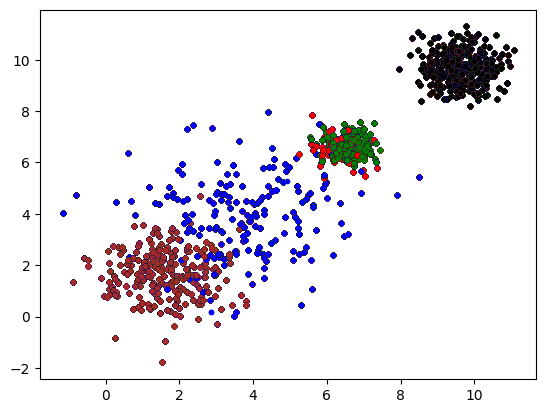

In [3]:
# print(true_m)
colors = plt.cm.rainbow(np.linspace(0, 1, len(true_m)))
colors = ['red','blue', 'green', 'brown', 'black']
# print(colors)
for i in range(n_samples):
  col = int(true_m[i])
  # print(col)
  plt.plot(x[i:,0],x[i:,1],linestyle="",marker=".", color=colors[col])
# plt.plot()

In [34]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.stats import special_ortho_group as sog

def generate_priors(uniform_prior, num_clusters):
  if uniform_prior:
    priors = [1/num_clusters for _ in range(num_clusters)]
  else:
    priors = np.random.rand(num_clusters) # Generating the true weights
    priors /= priors.sum()
  priors = np.array(priors)
  return priors

def generate_covariance(shared_covariance, covariance_type, sigma_cov, num_clusters, num_features):
  covariances = np.zeros((num_clusters, num_features, num_features))
  match covariance_type:

    case 'spherical':
      for i in range(num_clusters):
        a,b = np.random.normal(0, sigma_cov, 2)
        cov = a**2 + b**2
        cov_matrix = np.diag(np.full(num_features, cov))
        covariances[i] = (cov_matrix)

    case 'diagonal':
      for i in range(num_clusters):
        cov_vec = np.zeros(num_features)
        for j in range(num_features):
          a,b = np.random.normal(0, sigma_cov, 2)
          cov = a**2 + b**2
          cov_vec[j] = cov

        cov_matrix = np.diag(cov_vec)
        covariances[i] = (cov_matrix)

    case 'full':
       for i in range(num_clusters):
        x = np.zeros((num_features+1,2))
        for j in range(num_features+1):
         x[j] = np.random.normal(0,sigma_cov,2)
        rand_matrix = np.random.normal(0, sigma_cov, (num_features+1, num_features))
        cov = np.cov(rand_matrix, rowvar=False) # Setting rowvar to false treats each column of the random matrix as a feature
        covariances[i] = (cov)




  if shared_covariance:
    for i in range(num_clusters):
      covariances[i] = covariances[0]

  return covariances


def generate_data(num_samples, num_features, uniform_prior, cov_type, shared_covariance, num_clusters, separation):
  priors = generate_priors(uniform_prior, num_clusters)
  sigma_cov = 1
  sigma_mean = separation * sigma_cov
  means = np.random.normal(0, sigma_mean, (num_clusters, num_features))
  covariances = generate_covariance(shared_covariance, cov_type, sigma_cov, num_clusters, num_features)
  gaussian_choice = np.random.choice(num_clusters, size=num_samples, p=priors)
  x = np.zeros((num_samples, num_features))
  true_k = np.zeros(num_samples)
  for i in range(num_samples):
    k = gaussian_choice[i]
    true_k[i] = k
    x[i] = np.random.multivariate_normal(means[k], covariances[k], 1)

  true_k = true_k.astype(int)
  return x, true_k, means, covariances, priors






[2 2 2 0 0 1 0 0 2 0 0 2 2 0 2 2 1 0 2 0 0 0 0 0 2 0 0 2 2 2 2 1 1 2 2 2 0
 2 0 0 2 0 2 0 0 0 0 0 2 2 2 2 2 1 0 2 2 2 1 2 0 1 2 1 0 0 1 2 2 2 2 2 0 0
 2 0 2 0 2 0 2 2 2 2 2 2 2 2 1 0 0 0 0 2 2 2 0 2 1 2 2 2 2 2 0 2 1 2 0 0 2
 2 2 0 0 2 0 1 0 0 2 2 0 2 2 2 2 2 0 0 2 2 2 1 2 0 2 1 2 2 0 0 2 0 2 1 0 2
 0 2 2 0 1 0 2 2 2 0 0 2 2 0 0 0 2 0 2 0 0 2 2 0 2 0 2 0 2 2 2 2 0 0 0 2 2
 2 2 1 0 2 0 2 0 0 0 2 0 2 2 0 2 0 0 2 0 0 1 2 2 2 0 0 1 2 2 0 2 0 0 1 2 0
 0 0 2 0 2 0 2 2 2 0 0 0 2 0 0 2 0 0 1 0 1 2 0 1 0 0 2 0 2 2 2 0 1 2 2 2 2
 2 2 0 0 0 2 0 2 1 0 2 2 2 0 0 0 1 0 0 0 1 0 2 0 0 2 2 0 0 0 0 2 2 2 2 0 2
 2 0 0 0 1 1 2 2 2 0 0 2 0 2 0 0 0 1 2 1 2 2 1 2 2 2 2 2 0 0 0 2 2 0 2 2 2
 2 2 2 2 1 2 2 2 2 2 2 1 0 1 2 0 0 2 0 0 1 0 2 2 2 0 2 2 0 2 2 1 0 2 0 2 2
 2 0 2 0 2 0 2 2 0 2 2 2 2 0 0 1 2 0 2 0 0 0 2 1 0 2 0 0 2 0 2 2 0 2 2 1 2
 2 2 0 2 1 2 0 2 1 1 2 2 0 2 2 0 0 0 2 2 1 2 2 2 0 2 0 2 2 0 0 2 0 2 0 2 0
 2 0 2 0 2 2 2 1 2 1 2 2 2 2 1 1 2 1 2 2 0 2 2 1 0 2 2 2 0 2 2 2 2 2 2 2 1
 0 2 0 1 2 0 2 0 0 0 0 2 

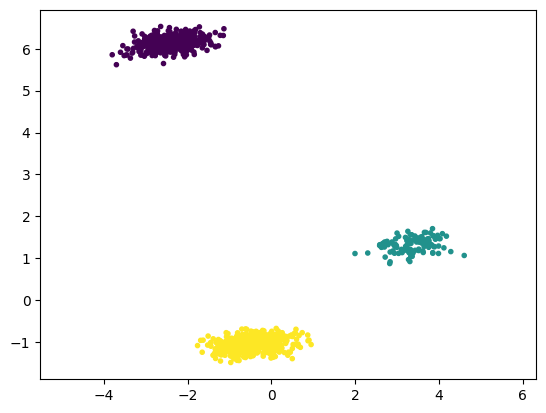

In [35]:
# Testing generate data
num_samples = 1000
num_features = 2
num_clusters = 3
uniform_prior = False
covariance = 'full'
shared_covariance = True
separation = 5

X, membership, means, covariances, priors = generate_data(num_samples, num_features, uniform_prior, covariance, shared_covariance, num_clusters, separation)
print(membership)
plt.scatter(X[:,0], X[:,1], c=membership, marker='.')
plt.axis('equal')
plt.show()


In [38]:
# Now the clusters function
from scipy.stats import multivariate_normal as mvn

def generate_priors(uniform_prior, num_clusters):
  if uniform_prior:
    priors = [1/num_clusters for _ in range(num_clusters)]
  else:
    priors = np.random.rand(num_clusters) # Generating the true weights
    priors /= priors.sum()
  priors = np.array(priors)
  return priors

def reshape_covariance(covariances,  num_features, covariance_type, num_clusters):
  match covariance_type:
    # If spherical then get the trace, divide by number of features, multiply by id.
    case 'spherical':
      for k in range(num_clusters):
              covariances[k] = (np.trace(covariances[k]) / num_features) * np.eye(num_features)
    # If diagonal just keep the diagonal members
    case 'diagonal':
      for k in range(num_clusters):
                # Set off-diagonal elements to zero while keeping diagonal elements
                # diagonal_elements = np.diag(covariances[k])  # Extract diagonal
                covariances[k] = np.multiply(np.eye(num_features), covariances[k])  # Reconstruct diagonal matrix

  #No case for full as we just return the full covariance
  return covariances



def covariance_shared_not_fuzzy(X, means, N, membership, num_features, num_clusters):
  covariance_sum = np.zeros((num_features, num_features))
  for i in range(N):
      diff = X[i] - means[membership[i]]
      covariance_sum += np.outer(diff, diff)

  shared_covariance = covariance_sum / N
  # shared_covariance *= num_clusters
  #
  covariances = np.array([shared_covariance.copy() for _ in range(num_clusters)])
  return covariances

def covariance_shared_fuzzy(X, means, N, membership, num_features, num_clusters):
  covariance_sum = np.zeros((num_features, num_features))
  total_weight = 0
  for i in range(N):
    for k in range(num_clusters):
      weight = membership[i, k]
      diff = X[i] - means[k]
      covariance_sum += weight * np.outer(diff, diff)
      total_weight += weight
  shared_covariance = covariance_sum / N
  covariances = np.array([shared_covariance.copy() for _ in range(num_clusters)])
  return covariances


def covariance_not_shared_not_fuzzy(X, means, N, membership, num_features, num_clusters):
  numerator = np.zeros((num_clusters, num_features, num_features))
  denominator = np.zeros(num_clusters)
  for i in range(N):
    cluster = membership[i]
    diff = X[i] - means[cluster]
    numerator[cluster] += np.outer(diff, diff)
    denominator[cluster] += 1

  covariances = np.zeros((num_clusters, num_features, num_features))
  for k in range(num_clusters):
        if denominator[k] > 0:
            covariances[k] = numerator[k] / denominator[k]
        else:
            print(f"Warning: Cluster {k} has no members, covariance is zero.")
            covariances[k] = np.zeros((num_features, num_features))
  return covariances

def covariance_not_shared_fuzzy(X, means, N, membership, num_features, num_clusters):
  numerator = np.zeros((num_clusters, num_features, num_features))
  denominator = np.zeros(num_clusters)
  for i in range(N):
    for k in range(num_clusters):
                weight = membership[i, k]
                diff = X[i] - means[k]
                numerator[k] += weight * np.outer(diff, diff)
                denominator[k] += weight

  covariances = np.zeros((num_clusters, num_features, num_features))
  for k in range(num_clusters):
        if denominator[k] > 1e-10:
            covariances[k] = numerator[k] / denominator[k]
        else:
            print(f"Warning: Cluster {k} has negligible membership, covariance is zero.")
            covariances[k] = np.zeros((num_features, num_features))
  return covariances


def update_means(X, means, num_clusters, membership, N, num_features, fuzzy):

    numerator = np.zeros((num_clusters, num_features))
    denominator = np.zeros(num_clusters)

    if fuzzy:
        # Soft clustering: use membership probabilities
        for i in range(N):
            for k in range(num_clusters):
                weight = membership[i, k]
                numerator[k] += weight * X[i]
                denominator[k] += weight
    else:
        # Hard clustering: use cluster indices
        for i in range(N):
            cluster = membership[i]
            numerator[cluster] += X[i]
            denominator[cluster] += 1

    # Compute means
    for k in range(num_clusters):
        if denominator[k] > 0:
            means[k] = numerator[k] / denominator[k]
        else:
            print(f"Warning: Cluster {k} has no members, mean unchanged.")

    return means

def update_priors(priors, fuzzy, membership, num_clusters, N):
  # Need to determine which is the most likely cluster to update priors
  if fuzzy:
    for i in range(N):
      for k in range(num_clusters):
        priors[k] = membership[i][k]
  else:
    for k in range(num_clusters):
      count = np.count_nonzero(membership == k)
      priors[k] = count / N

  return priors

def cluster (X, num_clusters, max_iter, initial_means, fuzzy, covariance_type, shared_covariance, uniform_prior):
  N = len(X)
  num_features = X.shape[1]

  covariances = np.array([np.eye(num_features) for _ in range(num_clusters)]) # Creating an initial id matrix for covariance

  # We now need initial weights, assumed to be equal.
  priors = generate_priors(num_clusters=num_clusters, uniform_prior=True)

  # Setting up the membership arrays
  membership = np.zeros((N, num_clusters)) if fuzzy else np.zeros(N)

  history = np.zeros(max_iter)

  # This is the membership loop. May want to make it a function. Not sure yet.
  for iter in range(max_iter):
    total_loss = 0
    for i in range(N):
      prob_array = np.zeros(num_clusters)
      for k in range(num_clusters):
        prob_array[k] = mvn.pdf(X[i], initial_means[k], covariances[k]) * priors[k]
        # prob_array[k] =  - np.log(mvn.pdf(X[i], initial_means[k], covariances[k]) * priors[k])
      likelihood = prob_array.sum()
      total_loss -= np.log(likelihood)
      prob_array /= likelihood
      if fuzzy:
        membership[i] = prob_array
      else:
        membership[i] = np.argmax(prob_array)

    if not fuzzy: membership = membership.astype(int)

    history[iter] = total_loss
    # Update stage
    means = update_means(X, initial_means, num_clusters, membership, N, num_features, fuzzy)
    if (not uniform_prior): priors = update_priors(priors, fuzzy, membership, num_clusters, N)
    if not fuzzy and shared_covariance:       covariances = covariance_shared_not_fuzzy(X, means, N, membership, num_features, num_clusters)
    elif fuzzy and shared_covariance:         covariances = covariance_shared_fuzzy(X, means, N, membership, num_features, num_clusters)
    elif not fuzzy and not shared_covariance: covariances = covariance_not_shared_not_fuzzy(X, means, N, membership, num_features, num_clusters)
    else: covariances = covariance_not_shared_fuzzy(X, means, N, membership, num_features, num_clusters)
    covariances = reshape_covariance(covariances, num_features, covariance_type, num_clusters)

  return membership, history, means, covariances, priors


[[2.62870953e-13 0.00000000e+00 1.00000000e+00]
 [1.25892347e-13 0.00000000e+00 1.00000000e+00]
 [1.35207882e-14 0.00000000e+00 1.00000000e+00]
 ...
 [2.93660891e-14 0.00000000e+00 1.00000000e+00]
 [6.05717152e-14 0.00000000e+00 1.00000000e+00]
 [9.63475489e-14 0.00000000e+00 1.00000000e+00]]


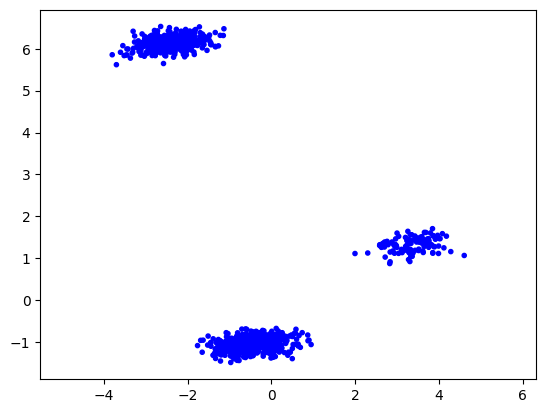

[  3804.23474837  12819.37626018 174084.14499555   4456.40181419
   4483.73299767   4444.32580009   4425.11930981   4458.29665914
   4432.5911422    4432.58691594]


In [40]:
fuzzy = True
max_iter = 10
uniform_prior = False
shared_covariance = True
covariance = 'full'
# Generate the initial means by sampling random data from X
initial_means = X[np.random.randint(0, len(X), size=num_clusters)]
membership,history , means, covariances, priors = cluster(X, num_clusters, max_iter, initial_means, fuzzy, covariance, shared_covariance, uniform_prior)
# print((membership[0]))
print(membership)

plt.scatter(X[:,0], X[:,1], c=membership, marker='.')
plt.axis('equal')
plt.show()
print(history)

In [20]:
arr = np.array([1, 2, 3, 4, 5])
max_index = np.argmax(arr)
print(max_index)
print(np.eye(5))
print(np.identity(5))

4
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [ ]:
# useful dead ends
 # Trying to redo the above loop but without cycling through each data point
  # prob_array = np.zeros(num_clusters)
  # for k in range(num_clusters):
  #   prob_array[k] = mvn.pdf(X[i], initial_means[k], covariances[k]) + priors[k]
  # prob_array /= prob_array.sum()
  # if fuzzy:
  #     membership = prob_array
  # else:
  #     membership = np.argmax(prob_array)

  # for i in range(N):
  #   log_prob_array = np.zeros(num_clusters)
  #   for k in range(num_clusters):
  #       log_prob_array[k] = np.log(mvn.pdf(X[i], initial_means[k], covariances[k])) + np.log(priors[k])
  #   log_prob_array -= np.max(log_prob_array)  # For numerical stability
  #   prob_array = np.exp(log_prob_array)
  #   prob_array /= prob_array.sum()

  #   if fuzzy:
  #       membership[i] = prob_array
  #   else:
  #       membership[i] = np.argmax(prob_array)



  # def update_mean_hard(X, means, num_clusters, membership, N, num_features):
#   # Want the count of elements currently members of a given cluster as denominator. As numerator want to multiple that number
#   numerator = np.zeros((num_clusters, num_features))
#   denominator = np.zeros(num_clusters)
#   for i in range(N):
#       cluster = membership[i]
#       numerator[cluster] += X[i]
#       denominator[cluster] += 1

#   for k in range(num_clusters):
#     if denominator[k] > 0:
#         means[k] = numerator[k] / denominator[k]
#     else:
#         print(f"Warning: Cluster {k} has no members, mean unchanged.")
#   return means

# def update_mean_soft(X, means, num_clusters, membership, N, num_features):
#   numerator = np.zeros((num_clusters, num_features))
#   denominator = np.zeros(num_clusters)
#   for i in range(N):
#       for k in range(num_clusters):
#         weight = membership[i, k]
#         numerator[k] += weight * X[i]
#         denominator[k] += weight

#   for k in range(num_clusters):
#         if denominator[k] > 0:
#             means[k] = numerator[k] / denominator[k]
#         else:
#             print(f"Warning: Cluster {k} has no effective members, mean unchanged.")

#   return means